In [1]:
!pip install luwiji

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from luwiji.cluster import demo

# **Sample Data**

In [3]:
X1, y1 = demo.blob_data()
X2, y2 = demo.moon_data()
X3, y3 = demo.circle_data()

# **Visualize**

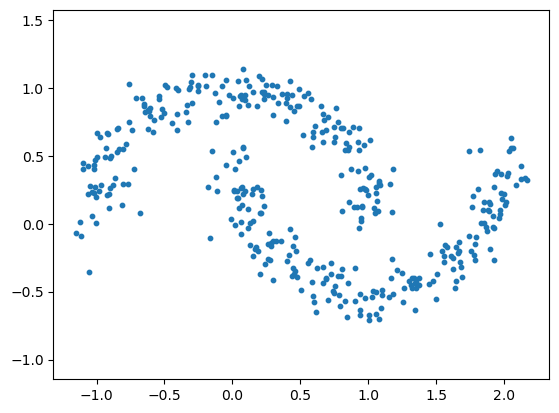

In [9]:
X = X2#X1 blob data
        #X1 moon data
        #X3 circle data
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.axis("equal");

# **K-Means Clustering**

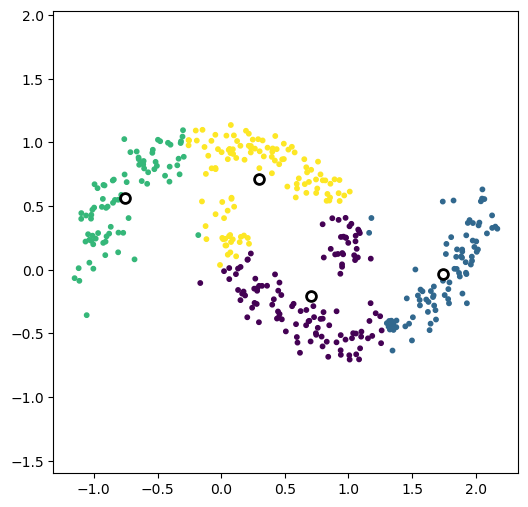

In [10]:
X = X2 #change to X2 for data demo X2 and so on
kmeans = KMeans(n_clusters=4) #X1 has 4 clusters, obviously
#kmeans.fit(X) #we fit only X without y, because unsupervised (clustering) has no label
member = kmeans.fit_predict(X) #save time, directly fit and predict clusters
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
#plt.scatter(X[:, 0], X[:, 1], s=10)
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

In [11]:
member

array([3, 0, 3, 3, 3, 3, 1, 3, 0, 2, 0, 1, 3, 3, 2, 3, 0, 1, 3, 1, 3, 0,
       1, 0, 0, 1, 2, 0, 0, 3, 1, 2, 0, 3, 0, 3, 3, 1, 2, 2, 1, 3, 3, 3,
       3, 1, 2, 2, 0, 2, 3, 1, 1, 3, 1, 3, 3, 2, 0, 2, 2, 0, 0, 3, 3, 3,
       1, 0, 1, 3, 1, 2, 0, 3, 1, 0, 3, 1, 2, 0, 0, 0, 3, 0, 0, 3, 0, 0,
       3, 3, 0, 1, 3, 3, 2, 0, 1, 1, 0, 3, 0, 3, 0, 3, 2, 0, 0, 2, 1, 1,
       2, 1, 0, 1, 0, 3, 3, 0, 0, 0, 2, 3, 0, 1, 0, 2, 1, 1, 2, 0, 0, 2,
       0, 2, 3, 2, 0, 0, 3, 0, 0, 2, 0, 2, 2, 0, 3, 3, 2, 1, 0, 1, 0, 2,
       0, 2, 3, 3, 1, 1, 1, 3, 0, 2, 1, 3, 1, 2, 2, 3, 3, 3, 3, 3, 2, 0,
       3, 0, 3, 0, 3, 2, 2, 2, 3, 2, 1, 2, 1, 2, 2, 2, 1, 3, 1, 1, 1, 1,
       1, 0, 2, 3, 0, 3, 0, 2, 3, 0, 1, 2, 3, 2, 2, 1, 0, 3, 1, 0, 1, 0,
       1, 2, 0, 2, 2, 2, 2, 1, 0, 3, 3, 0, 0, 0, 2, 1, 3, 1, 1, 1, 1, 2,
       3, 1, 3, 3, 1, 3, 0, 0, 2, 0, 2, 0, 3, 1, 3, 3, 0, 2, 2, 0, 0, 1,
       2, 2, 1, 0, 3, 3, 3, 0, 0, 0, 2, 3, 0, 3, 0, 1, 0, 0, 1, 3, 3, 1,
       3, 2, 3, 3, 3, 0, 3, 0, 3, 1, 0, 0, 0, 0, 0,

In [12]:
kmeans.cluster_centers_ # to see centroids

array([[ 0.70882511, -0.20631953],
       [ 1.74216345, -0.03095156],
       [-0.75287613,  0.56300973],
       [ 0.29451941,  0.71603075]])

# **Weaknesses of K-Means:**


1. Difficult to determine the value of K
* Solution: Use the Elbow Method, Silhouette Score, and other techniques.
2. Only applicable to data that can be averaged
* Solution: Use K-Medoids instead.
3. The solution is not always optimal
* Works only for linearly separable data

# **Example: Moon Dataset**

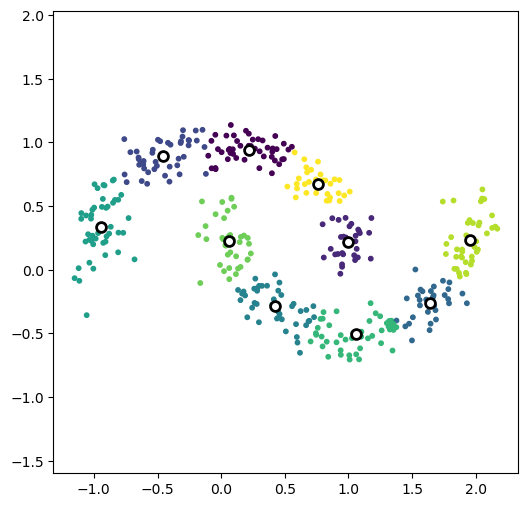

In [13]:
X = X2
kmeans = KMeans(n_clusters=10) # check k=2 or k=3 or k=3 and see the result.
                              # do the same to X3
member = kmeans.fit_predict(X)
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.scatter(centre[:, 0], centre[:, 1], c="w", edgecolors="k", s=50, linewidths=2)
plt.axis("equal");

# **Determining K (number of clusters) using Elbow Analysis**


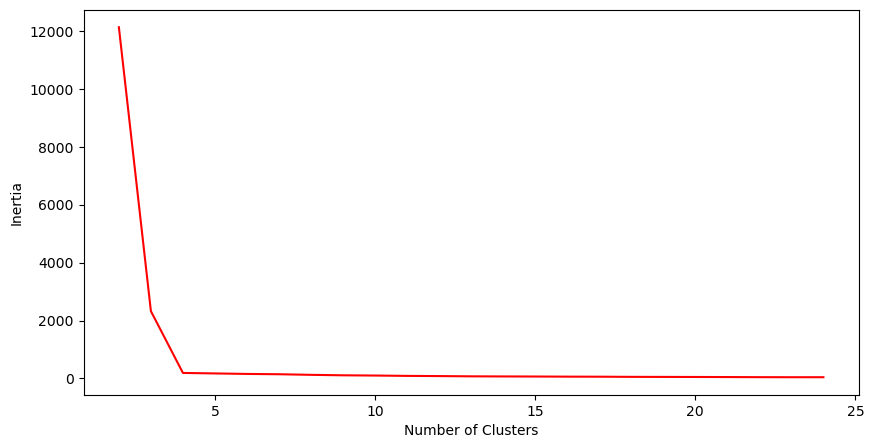

In [14]:
X = X1
score = []
for k in range(2, 25):
    kmeans = KMeans(n_clusters=k)
    member = kmeans.fit_predict(X)
    score.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot( range(2, 25), score, "r-")
plt.ylabel("Inertia")
plt.xlabel("Number of Clusters");

# **Determining K (number of clusters) using the Silhouette Score (requires labeled data)**

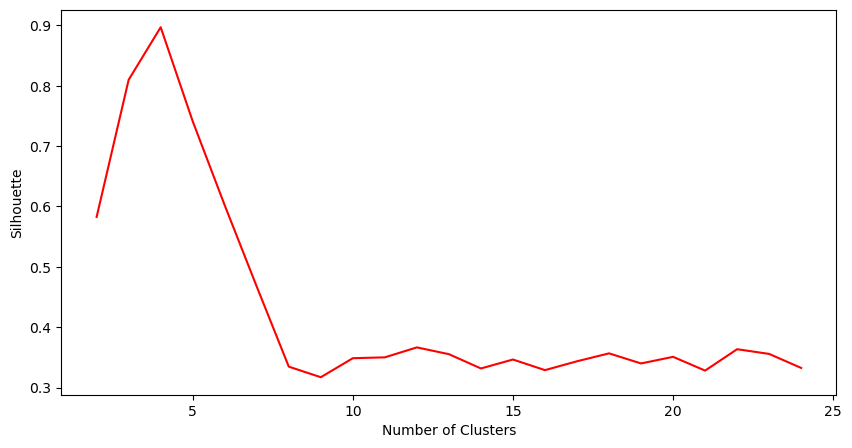

In [15]:
X = X1
score = []
for k in range(2, 25):
    kmeans = KMeans(n_clusters=k)
    member = kmeans.fit_predict(X)
    silhouette = silhouette_score(X, member, metric='euclidean')
    score.append(silhouette)

plt.figure(figsize=(10, 5))
plt.plot( range(2, 25), score, "r-")
plt.ylabel("Silhouette")
plt.xlabel("Number of Clusters");

**In unsupervised learning, there is no such thing as the “best model.” There is almost no notion of right or wrong. This is because there are no labels used as a point of reference.**

**Even though we may have successfully determined an appropriate value of K, K-Means can still fail, and it does not always guarantee success. As discussed earlier, some weaknesses of K-Means are:**
* The solution is not always optimal, and
* It only works well for linearly separable data.

Linearly separable means that we can draw a straight line (in 2D), a plane (in 3D), or a flat hyperplane (in higher dimensions) that perfectly separates the data points into different classes or groups.



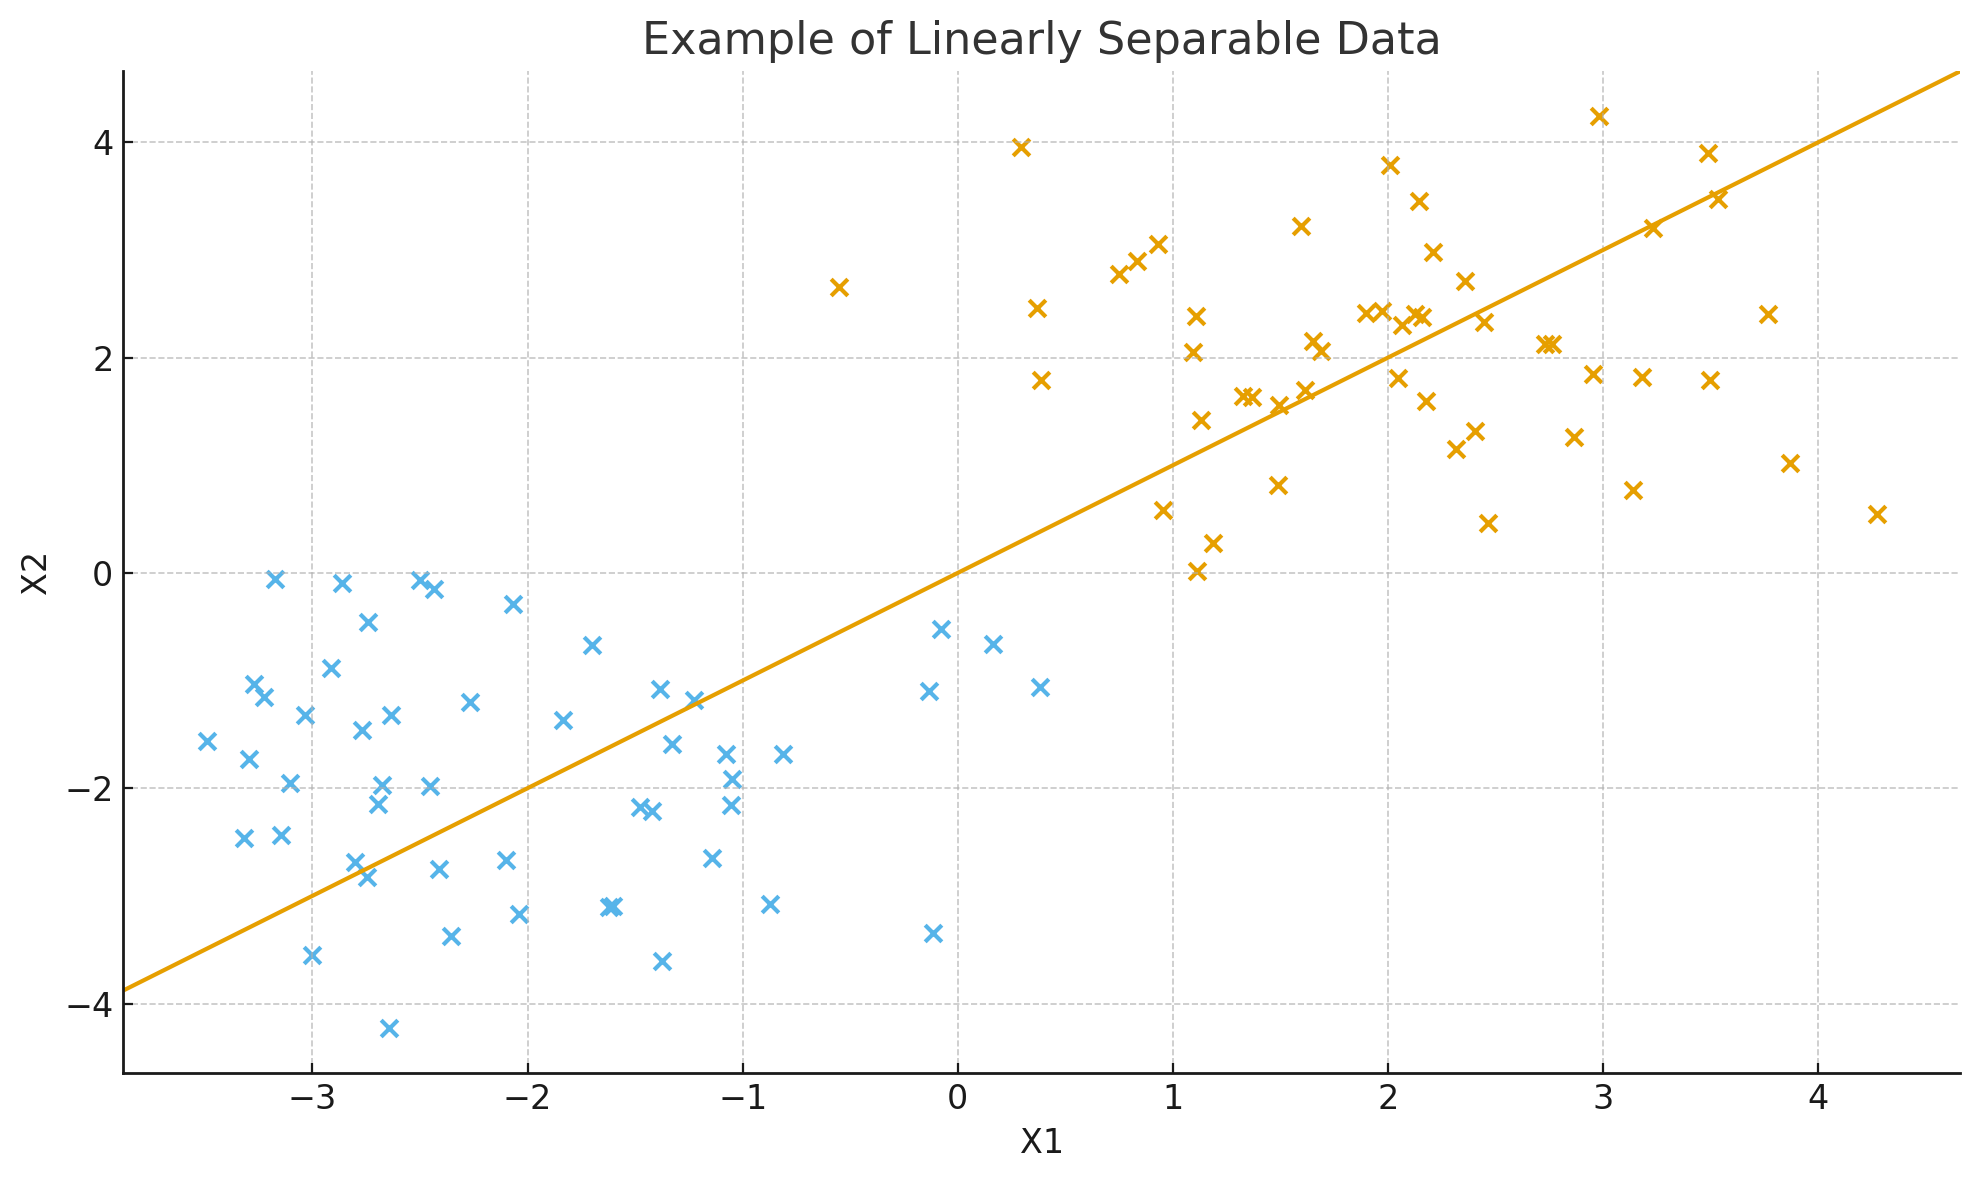

**In the demo datasets X2 and X3, the weaknesses of K-means in performing clustering are clearly visible. Even though optimization has been attempted using methods like the elbow method to determine K, for example, common sense tells us that the X2 demo dataset should naturally consist of two clusters.**



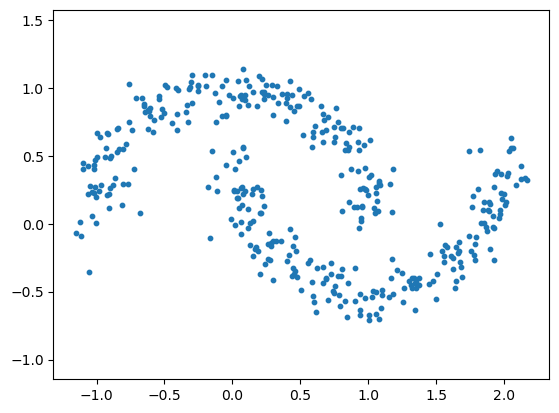

In [16]:
X = X2  #X1 blob data
        #X1 moon data
        #X3 circle data
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.axis("equal");

# **Beyond K-Means**

**Spectral Clustering**
* Uses global relationships between points (graph structure)
* Works when K-means fails

in python, it uses gamma for tuning purpose.
In spectral clustering, gamma (γ) is a parameter used when constructing the similarity matrix, especially when using the RBF (Gaussian) kernel to measure similarity between points.



> In clustering and machine learning, the term usually refers to the RBF kernel, which measures similarity between two points based on their distance.

**How to choose gamma?**

There’s no fixed rule, but common approaches is to try multiple values and pick the one yielding the best separation (tuning).


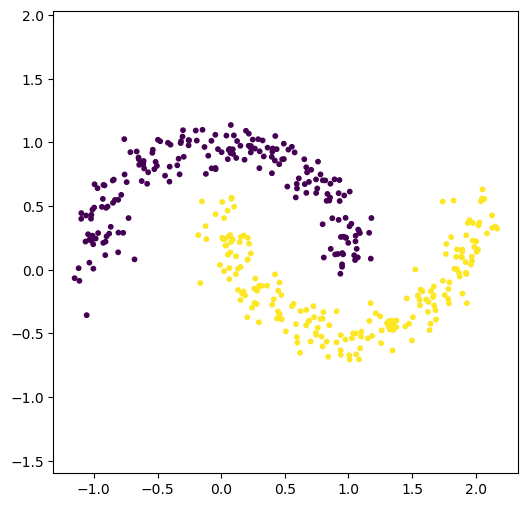

In [17]:
from math import gamma
from sklearn.cluster import SpectralClustering
X = X2
sc = SpectralClustering(n_clusters=2, gamma=40) #try without gamma, and with gamma < 40
member = sc.fit_predict(X)
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.axis("equal");

more about Spectral Clustering:
* https://scikit-learn.org/stable/auto_examples/bicluster/plot_spectral_coclustering.html
* https://www.kaggle.com/code/oscarm524/intro-to-spectral-clustering-a-toy-example

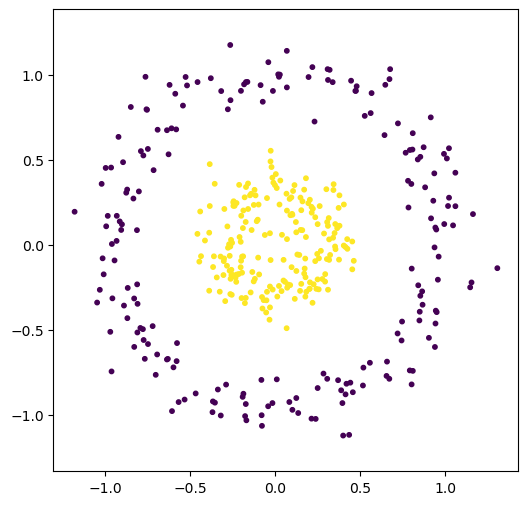

In [18]:
X = X3
sc = SpectralClustering(n_clusters=2, gamma=40) #try without gamma, and with gamma < 40
member = sc.fit_predict(X)
centre = kmeans.cluster_centers_

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.axis("equal");

**DBSCAN**


stands for Density-Based Spatial Clustering of Applications with Noise.
It is a popular unsupervised clustering algorithm that groups data based on density, not distance or shape.

It works based on two key parameters:
* **ε (epsilon)** – the radius of the neighborhood
* **min_samples** – minimum number of points needed to form a dense region



**How it works?**

For each point:

1. Core Point

* If at least min_samples points are within distance ε → it becomes a core point and starts a cluster.

2. Border Point

* Within distance ε of a core point but has fewer than min_samples neighbors.

3. Noise Point

* Not close enough to any core point → considered outlier.

* DBSCAN expands clusters by connecting nearby core points.


**Advantages of DBSCAN**

* Can find clusters of arbitrary shape (circles, spirals, moons)
* Automatically identifies outliers
* Does NOT require specifying the number of clusters
* Good when cluster densities vary and shapes are complex

DEMO: https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/


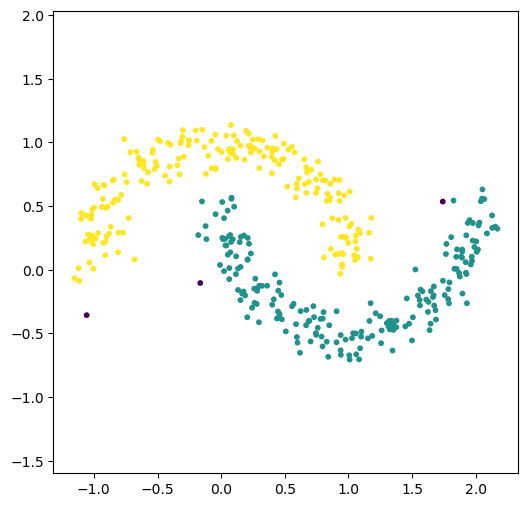

In [19]:
from sklearn.cluster import DBSCAN
X = X2
dbscan = DBSCAN(eps=0.2) #DBSCAN has no K, but epsilon, with range eps ≥ 0
member = dbscan.fit_predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.axis("equal");

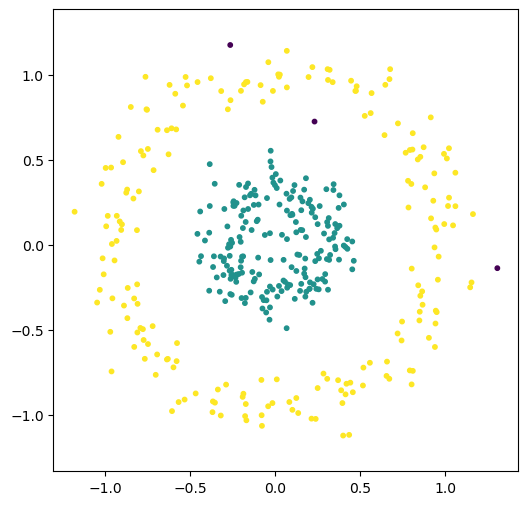

In [20]:
from sklearn.cluster import DBSCAN
X = X3
dbscan = DBSCAN(eps=0.2) #DBSCAN has no K, but epsilon, with range eps ≥ 0
member = dbscan.fit_predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.axis("equal");

**AHC**


Stands for agglomerative Hierarchical Clustering. It is a type of hierarchical clustering that builds clusters bottom-up.

AHC starts with each data point as its own cluster, then repeatedly merges the two closest clusters until:
* a stopping condition is reached, or
* everything becomes one large cluster.


**How it works?**

1. Start with N clusters, each containing 1 point.
2. Compute distances between all clusters.
3. Merge the two closest clusters.
4. Recompute the distances.
5. Repeat until clusters cannot be merged further.

This produces a tree-like structure called a dendrogram, which shows the step-by-step merging process.

in AHC, we need to set linkage. in Sklearn, the available linkage are: "ward", "complete", "average", "single"


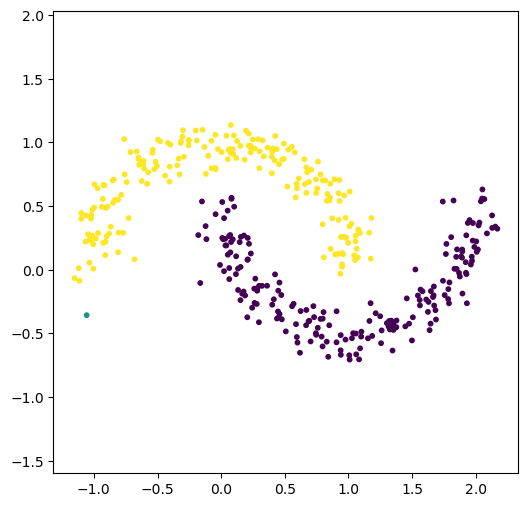

In [21]:
from sklearn.cluster import AgglomerativeClustering
X = X2
ahc = AgglomerativeClustering(n_clusters=3, linkage="single")   # Logically, AHC is a tree like clustering.
                                                                # So, n_cluster, i would say, in which cluster number i would to cut the hierarchy

# n_clusters=3 means produce exactly 3 clusters in the final output
# linkage="single" means merge clusters based on minimum distance between any two points

member = ahc.fit_predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10) #this with color
plt.axis("equal");

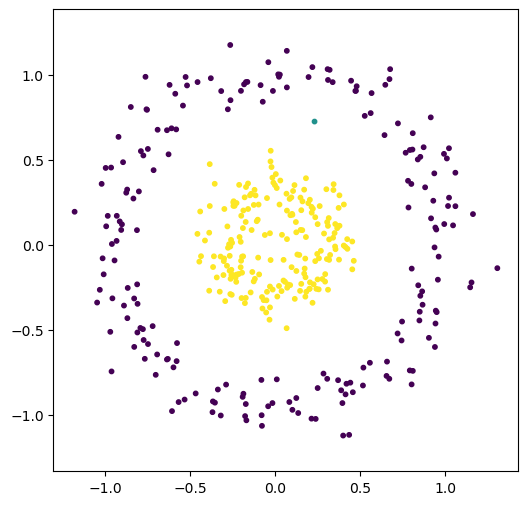

In [22]:
from sklearn.cluster import AgglomerativeClustering
X = X3
ahc = AgglomerativeClustering(n_clusters=3, linkage="single")

member = ahc.fit_predict(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=member, s=10)
plt.axis("equal");

**Clustering Summary**

In [23]:
from luwiji.cluster import illustration


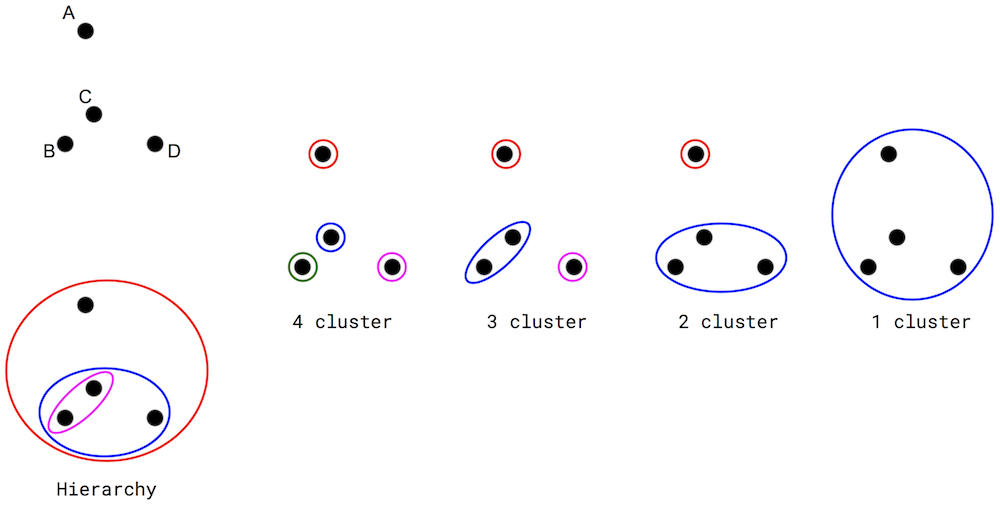

In [29]:
illustration.ahc

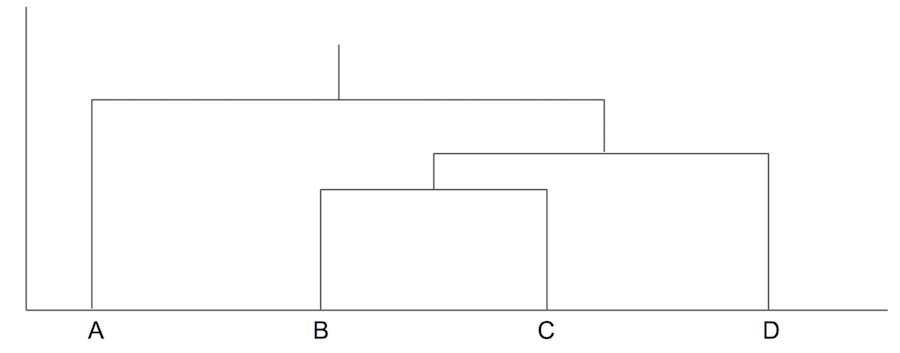

In [25]:
illustration.dendrogram

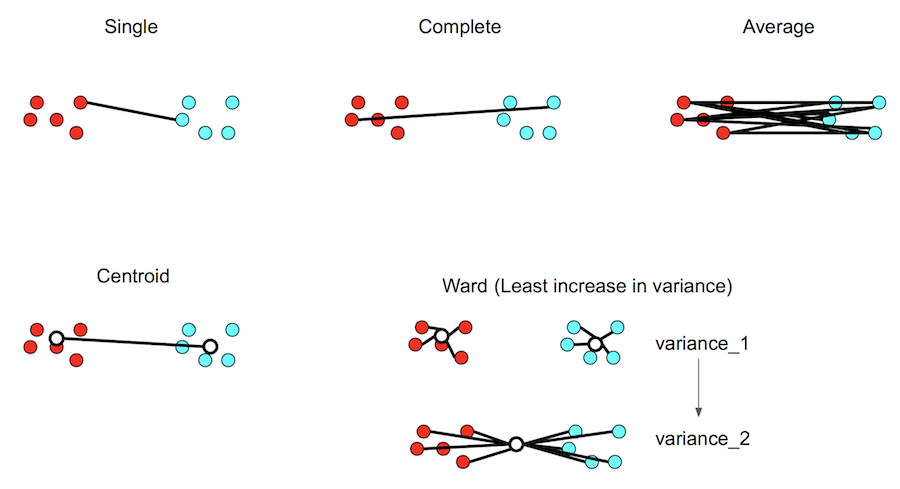

In [26]:
illustration.cluster_distance